Example code for "Formation of Bound States in the Continuum in Hybrid Plasmonic-Photonic Systems". The structure is a silver relief grating coupled to a SiO2 slab.

S. I. Azzam, V. M. Shalaev, A. Boltasseva, and A. V. Kildishev, “Formation of Bound States in the Continuum in Hybrid Plasmonic-Photonic Systems,” Physical Review Letters, vol. 121, no. 25, Dec. 2018, doi: https://doi.org/10.1103/physrevlett.121.253901.

The refractive index of silver is extracted from: https://refractiveindex.info/?shelf=main&book=Ag&page=Johnson

In [8]:
import numpy as np
from inkstone import Inkstone
from matplotlib import pyplot as plt
from helper_functions import *

# ========================
# 1. STRUCTURE DEFINITION
# ========================
def define_simulation(wavelength, angle):
    """Defines the simulation structure for a given wavelength and angle."""
    s = Inkstone()
    s.lattice = 0.4
    s.num_g = 30
    n_silver = get_refractive_index('dataset/silver.csv', wavelength)
    # Add materials
    s.AddMaterial(name='SiO2', epsilon=2.25)
    s.AddMaterial(name='silver', epsilon=n_silver**2)
    s.AddMaterial(name='glass', epsilon=1.4**2)

    # Add layers
    s.AddLayer(name='in', thickness=0, material_background='vacuum')
    s.AddLayer(name='SiO2', thickness=0.5, material_background='SiO2')
    s.AddLayer(name='Silver1', thickness=0.03, material_background='silver')
    s.AddLayer(name='Silver2', thickness=0.07, material_background='silver')
    s.AddLayer(name='Substrate', thickness=100, material_background='glass')
    s.AddLayerCopy(name='out', original_layer='in', thickness=0)

    # Add pattern
    s.AddPattern1D(layer='Silver1', pattern_name='box', material='SiO2', width=0.3, center=0.2)

    # Set excitation
    s.SetExcitation(theta=angle, phi=0, s_amplitude=1, p_amplitude=0)
    s.frequency = 1 / wavelength

    return s

# ========================
# 2. CALCULATION FUNCTIONS
# ========================

def calculate_field_intensity(wavelengths, angles, xmin=-0.4, xmax=0.4, zmin=-0.2, zmax=0.6, nx=101, nz=101):
    """Calculates the field intensity over a range of wavelengths and angles."""
    X, Y = np.meshgrid(wavelengths, angles)
    Z = np.zeros_like(X)

    for i, wavelength in enumerate(wavelengths):
        for j, angle in enumerate(angles):
            s = define_simulation(wavelength, angle)
            _, Ey, _, _, _, _ = s.GetFields(
                xmin=xmin, xmax=xmax, nx=nx,
                zmin=zmin, zmax=zmax, nz=nz,
                y=0
            )
            Z[j, i] = np.max(np.abs(Ey[0, :, :]))  # Store maximum field intensity

    return X, Y, Z

def calculate_flux(wavelengths, angle=2):
    """Calculates reflection and transmission for a range of wavelengths."""
    reflection, transmission = [], []
    flux_in, flux_out = [], []

    for wavelength in wavelengths:
        freq = 1 / wavelength
        s = define_simulation(wavelength, angle)  # Initial structure setup
        s.SetFrequency(freq)

        flux_in.append(s.GetPowerFlux('in'))
        flux_out.append(s.GetPowerFlux('out'))

    incident = np.array([a[0] for a in flux_in])
    reflection = -np.array([a[1] for a in flux_in]) / incident
    transmission = np.array([a[0] for a in flux_out]) / incident

    return wavelengths, reflection, transmission

# ========================
# 3. PLOTTING FUNCTIONS
# ========================

def plot_field_heatmap(wavelengths, angles, Z):
    """Plots a heatmap of field intensity."""
    plt.figure(figsize=(10, 8))
    plt.pcolormesh(wavelengths, angles, Z, shading='auto', cmap='viridis')
    plt.xlabel('Wavelength (nm)')
    plt.ylabel('Angle (degrees)')
    plt.colorbar(label='Field Intensity')
    plt.title('Field Intensity over Wavelength and Angle')
    plt.show()

def plot_flux(wavelengths, reflection, transmission):
    """Plots reflection and transmission over wavelength."""
    plt.figure(figsize=(10, 6))
    plt.plot(wavelengths, reflection, label='Reflection', color='red')
    plt.plot(wavelengths, transmission, label='Transmission', color='blue')
    plt.xlabel('Wavelength (nm)')
    plt.ylabel('Ratio')
    plt.legend()
    plt.title('Reflection and Transmission vs Wavelength')
    plt.grid()
    plt.show()


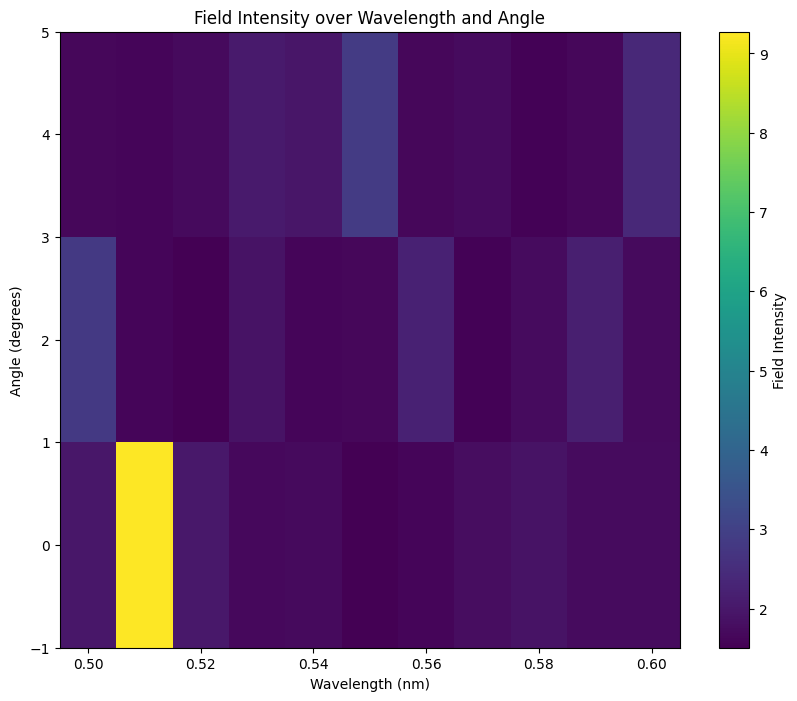

In [9]:
# ========================
# 4. MAIN SCRIPT
# ========================

# Parameters
wavelengths = np.linspace(0.5, 0.6, 11)
angles = np.linspace(0, 4, 3)

# Field Intensity Calculation
X, Y, Z = calculate_field_intensity(wavelengths, angles)
plot_field_heatmap(X, Y, Z)

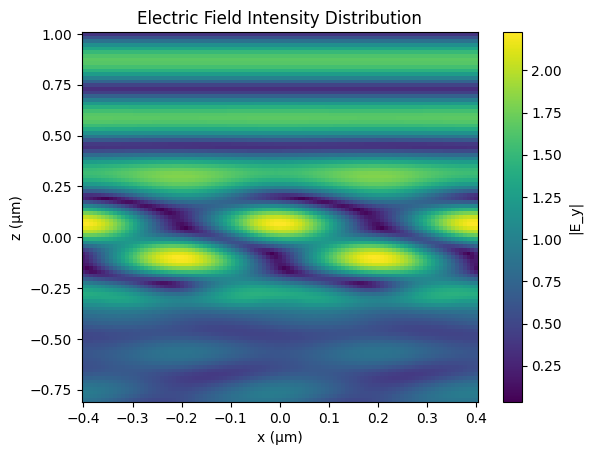

In [21]:
def calculate_fields(s, incident_wavelength, theta):
    s.SetExcitation(theta=theta, phi=0, s_amplitude=1, p_amplitude=0)
    s.frequency = 1 / incident_wavelength

    Ex, Ey, Ez, Hx, Hy, Hz = s.GetFields(
        xmin=-0.4, xmax=0.4, nx=101,
        zmin=-0.8, zmax=1, nz=101,
        y=0
    )
    return Ey

def plot_field(Ey):
    x = np.linspace(-0.4, 0.4, 101)
    z = np.linspace(1, -0.8, 101)

    plt.pcolormesh(x, z, np.abs(Ey[0, :, :]).T, shading='auto', cmap='viridis')
    plt.xlabel('x (µm)')
    plt.ylabel('z (µm)')
    plt.colorbar(label='|E_y|')
    plt.title('Electric Field Intensity Distribution')
    plt.show()

# Parameters
incident_wavelength = 0.56  # Wavelength in µm
angle = 2                  # Incident angle in degrees

# Define the structure
s = define_simulation(incident_wavelength, angle)


# Calculate the fields
Ey = calculate_fields(s, incident_wavelength, angle)

# Plot the electric field intensity
plot_field(Ey)